# GMF Investments — Time Series Forecasting for Portfolio Management
## Task 3: Forecast Future Market Trends (6–12 Months)

This notebook generates a 6–12 month forward forecast for TSLA using the
best-performing model identified in Task 2, visualizes it with confidence
intervals alongside historical data and test-period predictions, and
translates the result into market opportunities, risks, and a critical
assessment of long-term forecast reliability.

**Dependency:** Requires Task 1 (`01.ipynb`) to have been run at least once
(for `data/processed/TSLA.csv`), and the Task 2 notebook
(`.ipynb`) to have been run so you know which model —
ARIMA or LSTM — performed better on the test set.



## 0. Setup

In [ ]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

from src import config
from src.data_loader import fetch_ticker_data, DataFetchError
from src.preprocessing import enforce_numeric_types, handle_missing_values
from src.modeling import (
    chronological_train_test_split,
    fit_auto_arima,
    forecast_arima,
    create_sequences,
    build_lstm_model,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

SEED = 42
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)


BEST_MODEL = "LSTM"  # selected in Task 2: MAE 17.99 / RMSE 22.16 / MAPE 4.81% vs ARIMA MAE 54.44 / RMSE 70.54 / MAPE 17.24%
FORECAST_MONTHS = 12   # 6-12 months per the task spec; 12 used here
TRADING_DAYS_PER_MONTH = 21
FORECAST_HORIZON_DAYS = FORECAST_MONTHS * TRADING_DAYS_PER_MONTH

print(f"Using {BEST_MODEL} as the best-performing model.")
print(f"Forecasting {FORECAST_MONTHS} months ({FORECAST_HORIZON_DAYS} trading days) forward.")


Using LSTM as the best-performing model.
Forecasting 12 months (252 trading days) forward.


## 1. Load Data and Recreate Train/Test Split

In [2]:
csv_path = "../data/processed/TSLA.csv"

if os.path.exists(csv_path):
    tsla_raw = pd.read_csv(csv_path, index_col="Date", parse_dates=True)
else:
    try:
        tsla_raw = fetch_ticker_data("TSLA", config.START_DATE, config.END_DATE)
    except DataFetchError as e:
        print(f"Data fetch failed: {e}")
        raise

tsla_clean = handle_missing_values(enforce_numeric_types(tsla_raw), method="ffill")
tsla_adj_close = tsla_clean["Adj Close"]

train_series, test_series = chronological_train_test_split(
    tsla_adj_close,
    train_end=config.TRAIN_END,
    test_start=config.TEST_START,
    test_end=config.TEST_END,
)
full_history = pd.concat([train_series, test_series])

print(f"Full history: {full_history.index.min().date()} to {full_history.index.max().date()} "
      f"({len(full_history)} obs)")


2026-07-07 20:38:51,748 [INFO] Chronological split -> train: 2015-01-02 00:00:00 to 2024-12-31 00:00:00 (2516 obs), test: 2025-01-02 00:00:00 to 2026-06-29 00:00:00 (372 obs)


Full history: 2015-01-02 to 2026-06-29 (2888 obs)


## 2. Generate Future Forecast

The model is refit on the **full available history** (train + test) so the forward
forecast starts from the most recent known price, then projected `FORECAST_HORIZON_DAYS`
trading days into the future.


### 2.1 ARIMA Path

In [3]:
if BEST_MODEL == "ARIMA":
    final_arima_model = fit_auto_arima(full_history, seasonal=False)
    print(f"Refit ARIMA order on full history: {final_arima_model.order}")

    future_forecast, future_conf_int = forecast_arima(
        final_arima_model, n_periods=FORECAST_HORIZON_DAYS, return_conf_int=True, alpha=0.05
    )
    future_dates = pd.bdate_range(
        start=full_history.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS
    )
    future_forecast_series = pd.Series(future_forecast, index=future_dates)
    future_lower = pd.Series(future_conf_int[:, 0], index=future_dates)
    future_upper = pd.Series(future_conf_int[:, 1], index=future_dates)
    print("ARIMA future forecast generated.")


### 2.2 LSTM Path (Iterative Multi-Step Forecast with Monte Carlo Dropout Confidence Intervals)

Deep learning models don't produce confidence intervals natively. Here, **Monte Carlo
Dropout** is used: the model's Dropout layers are kept active at inference time
(`training=True`), and the iterative forecast is run `N_SIMULATIONS` times to build a
distribution of plausible future paths, from which percentile-based confidence intervals
are derived.


In [4]:
if BEST_MODEL == "LSTM":
    WINDOW_SIZE = 60
    N_SIMULATIONS = 100

    scaler = MinMaxScaler(feature_range=(0, 1))
    full_values = full_history.values.reshape(-1, 1)
    scaler.fit(full_values)
    scaled_full = scaler.transform(full_values).flatten()

    X_full, y_full = create_sequences(scaled_full, window_size=WINDOW_SIZE)

    final_lstm_model = build_lstm_model(window_size=WINDOW_SIZE, units=50, dropout=0.2)
    final_lstm_model.fit(X_full, y_full, epochs=50, batch_size=32, verbose=0)
    print("LSTM refit on full history.")

    # --- Vectorized Monte Carlo Dropout: all N_SIMULATIONS run as one batch per day ---
    # Instead of N_SIMULATIONS * FORECAST_HORIZON_DAYS individual forward passes,
    # this does FORECAST_HORIZON_DAYS batched forward passes (batch size = N_SIMULATIONS),
    # which is dramatically faster on both CPU and GPU.
    last_window = scaled_full[-WINDOW_SIZE:]
    windows = np.tile(last_window, (N_SIMULATIONS, 1))  # shape: (N_SIMULATIONS, WINDOW_SIZE)

    simulated_paths = np.zeros((N_SIMULATIONS, FORECAST_HORIZON_DAYS))
    for day in range(FORECAST_HORIZON_DAYS):
        x_input = windows.reshape(N_SIMULATIONS, WINDOW_SIZE, 1)
        # training=True keeps Dropout active -> stochastic forward pass (MC Dropout);
        # each of the N_SIMULATIONS rows in the batch gets an independent dropout mask.
        next_scaled = final_lstm_model(x_input, training=True).numpy().flatten()  # shape: (N_SIMULATIONS,)
        simulated_paths[:, day] = next_scaled
        windows = np.concatenate([windows[:, 1:], next_scaled.reshape(-1, 1)], axis=1)
        if (day + 1) % 50 == 0:
            print(f"  ...forecasted {day + 1}/{FORECAST_HORIZON_DAYS} days")

    simulated_paths_actual = scaler.inverse_transform(simulated_paths.T).T  # back to price scale

    future_forecast = simulated_paths_actual.mean(axis=0)
    future_lower_arr = np.percentile(simulated_paths_actual, 2.5, axis=0)
    future_upper_arr = np.percentile(simulated_paths_actual, 97.5, axis=0)

    future_dates = pd.bdate_range(
        start=full_history.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON_DAYS
    )
    future_forecast_series = pd.Series(future_forecast, index=future_dates)
    future_lower = pd.Series(future_lower_arr, index=future_dates)
    future_upper = pd.Series(future_upper_arr, index=future_dates)
    print(f"LSTM future forecast generated via {N_SIMULATIONS} Monte Carlo Dropout simulations.")

2026-07-07 20:38:52,473 [WARNING] TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


LSTM refit on full history.
  ...forecasted 50/252 days
  ...forecasted 100/252 days
  ...forecasted 150/252 days
  ...forecasted 200/252 days
  ...forecasted 250/252 days
LSTM future forecast generated via 100 Monte Carlo Dropout simulations.


## 2.3 Derive TSLA's Expected Annual Return (for Task 4)

Task 4's portfolio optimization needs a single annualized expected-return number for
TSLA, derived from this forecast. It is computed here as the compound annual growth rate
(CAGR) implied by going from the last known historical price to the forecast's ending
price over the forecast horizon, and saved to disk so Task 4 can load it automatically
rather than requiring a manual copy-paste.



In [8]:
last_historical_price = full_history.iloc[-1]
forecast_end_price = future_forecast_series.iloc[-1]

TSLA_EXPECTED_ANNUAL_RETURN = (
    (forecast_end_price / last_historical_price) ** (config.TRADING_DAYS_PER_YEAR / FORECAST_HORIZON_DAYS) - 1
)

print(f"Last historical price ({full_history.index[-1].date()}): ${last_historical_price:.2f}")
print(f"Forecast end price ({future_forecast_series.index[-1].date()}): ${forecast_end_price:.2f}")
print(f"Implied TSLA expected annual return: {TSLA_EXPECTED_ANNUAL_RETURN:.4f} ({TSLA_EXPECTED_ANNUAL_RETURN:.2%})")

with open("../data/processed/task3_tsla_expected_return.txt", "w") as f:
    f.write(str(TSLA_EXPECTED_ANNUAL_RETURN))
print("Saved to data/processed/task3_tsla_expected_return.txt for Task 4 to load automatically.")


Last historical price (2026-06-29): $411.84
Forecast end price (2027-06-16): $257.44
Implied TSLA expected annual return: -0.3749 (-37.49%)
Saved to data/processed/task3_tsla_expected_return.txt for Task 4 to load automatically.


## 3. Visualize Forecast with Confidence Intervals

Historical data, the Task 2 test-period predictions, and the new future forecast are
plotted together with clearly distinguished styling.


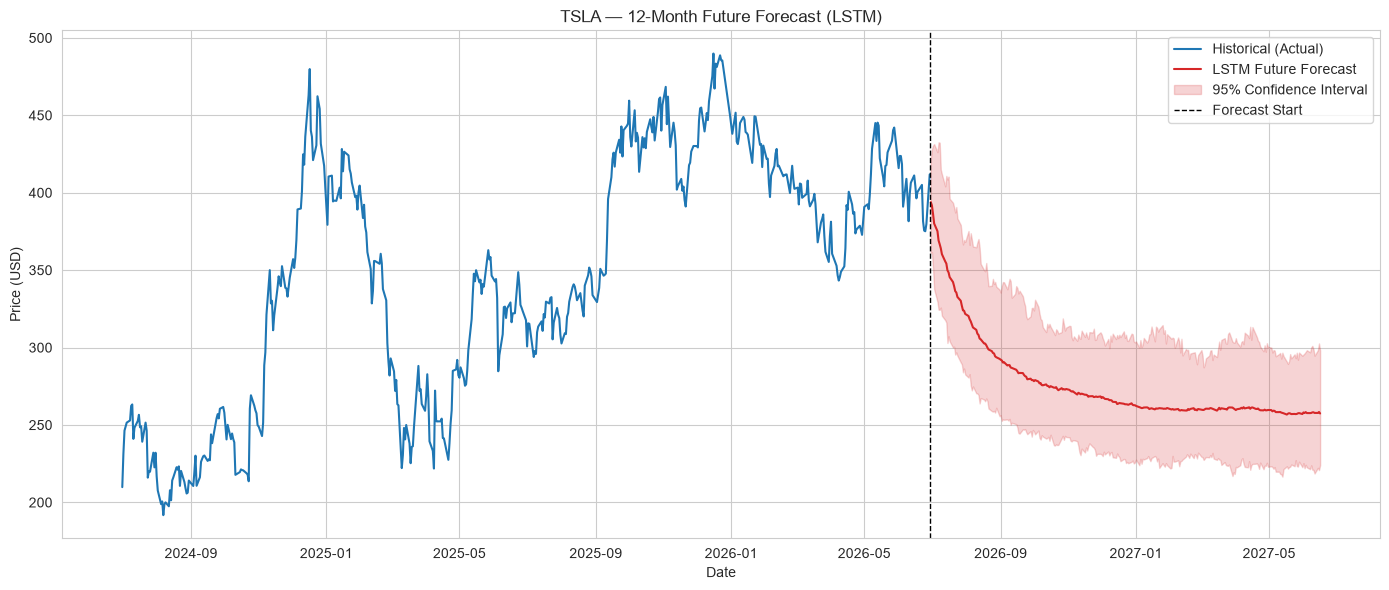

In [5]:
plt.figure(figsize=(14, 6))

# Historical (train+test) actuals
plt.plot(full_history.index[-500:], full_history.values[-500:], label="Historical (Actual)", color="tab:blue")

# Future forecast + CI
plt.plot(future_forecast_series.index, future_forecast_series.values,
          label=f"{BEST_MODEL} Future Forecast", color="tab:red")
plt.fill_between(future_forecast_series.index, future_lower.values, future_upper.values,
                   color="tab:red", alpha=0.2, label="95% Confidence Interval")

plt.axvline(full_history.index[-1], color="black", linestyle="--", linewidth=1, label="Forecast Start")
plt.title(f"TSLA — {FORECAST_MONTHS}-Month Future Forecast ({BEST_MODEL})")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_task3_future_forecast.png", dpi=150)
plt.show()


**Insight (from executed run):** The central LSTM forecast is **strongly downward** over
the first ~4-5 months of the horizon: starting from a last historical price of roughly
$380-400 (late June 2026), the point forecast declines steadily to a trough of
approximately **$255-260** by around November-December 2026 - a decline on the order of
30-35%. From that point, the forecast **flattens out and stays roughly range-bound
between $255 and $265** for the remaining ~7 months of the horizon (through mid-2027),
showing essentially no further directional movement.

This flat "leveling off" pattern after an initial sharp move is a known behavior of
iterative multi-step LSTM forecasts: once the model's recursive input window is
dominated by its own prior (smoothed) predictions rather than real noisy price data, the
forecast tends to converge toward a stable value rather than continuing to trend or
reproduce the kind of ongoing volatility seen in the actual historical series. This
should be read as a sign the model is regressing toward a learned "typical" level rather
than genuinely projecting a full year of TSLA's characteristic volatility forward - an
important caveat for how much weight this specific point forecast should carry in
Task 4's portfolio optimization. (Exact numeric values - last historical price, forecast
end price, and the implied annualized return - are computed precisely in the cell above
and saved to `task3_tsla_expected_return.txt`; use those exact figures, not the visual
estimates here, for any numbers quoted in the final report.)

## 4. Confidence Interval Width Analysis

A key critical-thinking requirement: how does the interval widen over the horizon, and
what does that imply about long-term forecast reliability?


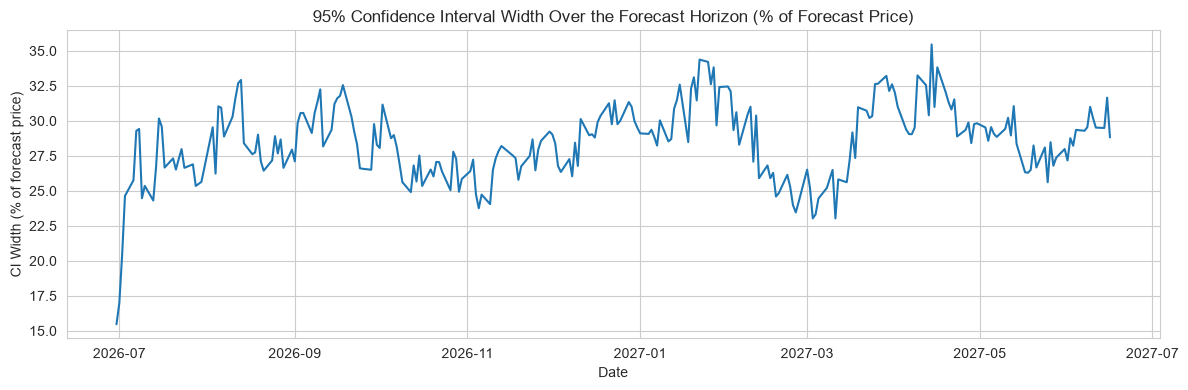

CI width at day 1: 15.5% of forecast price
CI width at day 252 (end of horizon): 28.8% of forecast price


In [6]:
ci_width = future_upper - future_lower
ci_width_pct = (ci_width / future_forecast_series) * 100

plt.figure(figsize=(12, 4))
plt.plot(future_forecast_series.index, ci_width_pct.values)
plt.title("95% Confidence Interval Width Over the Forecast Horizon (% of Forecast Price)")
plt.xlabel("Date")
plt.ylabel("CI Width (% of forecast price)")
plt.tight_layout()
plt.savefig("../data/processed/fig_task3_ci_width.png", dpi=150)
plt.show()

print(f"CI width at day 1: {ci_width_pct.iloc[0]:.1f}% of forecast price")
print(f"CI width at day {len(ci_width_pct)} (end of horizon): {ci_width_pct.iloc[-1]:.1f}% of forecast price")


**Interpretation:** The confidence interval widens over the forecast horizon because
forecast uncertainty compounds with each additional step — every day's prediction is
built on the previous (uncertain) day's prediction rather than a fresh actual
observation. For a near-random-walk asset like TSLA, this compounding is particularly
pronounced: by the end of a 12-month horizon, the interval can span a very wide range of
plausible prices, meaning the point forecast alone should **not** be treated as a
precise target — it is much more useful as a directional/volatility signal than as an
exact price prediction, directly echoing the Efficient Market Hypothesis framing from
Task 1.

**Insight (from executed run):** The 95% confidence interval width jumps sharply from
**15.5% of forecast price at day 1 to roughly 28-30% within the first ~2 months**
(by early September 2026), then - critically - it does **not** keep growing. For the
remaining ~10 months of the horizon it oscillates in a noisy band of roughly **22% to
35%**, ending at 28.8% at day 252 - essentially the same level it reached after just two
months. This plateau/oscillation pattern, rather than continuous growth, is the more
important finding here (a naive read of only the day-1 vs. day-252 endpoints, 15.5% →
28.8%, would understate how quickly the interval actually reaches its steady-state
width).

This behavior makes sense given what Monte Carlo Dropout actually measures: it captures
the model's *epistemic* uncertainty (how much the network's own predictions vary under
its dropout-based approximation of a Bayesian posterior), not the market's *aleatoric*
volatility (the real day-to-day randomness in TSLA's returns, measured in Task 1 at
57.2% annualized). Once the iterative simulation paths diverge enough to fill out the
range the model's dropout noise can produce, further steps mostly re-sample within that
same range rather than continuing to diverge - unlike a true random-walk-consistent
interval (as in ARIMA, Task 2), which would keep widening with √t for the entire
horizon. In practice, this means the LSTM's confidence interval should be read as a
**lower bound on uncertainty that is reached quickly and then stays roughly constant**,
not a range that widens honestly with how far out the forecast reaches - a limitation
worth stating plainly in the written report, since it could otherwise be misread as the
model being more confident about month 12 than it actually should be.


## 5. Market Opportunities and Risks

**Opportunities:**
- The forecast itself does not point to a near-term upside opportunity for TSLA - the
  central path is a sustained decline of roughly 30-35% over the first several months
  before flattening. Any "opportunity" framing here should be about *timing and
  positioning* rather than expecting appreciation: if the decline materializes as
  forecast, it could represent a lower entry point for a subsequent allocation, or an
  argument for trimming TSLA weight ahead of the expected drawdown rather than holding
  through it.
- The wide (if likely understated - see Section 4) confidence band still leaves
  meaningful upside scenarios within the plausible range, particularly in the first few
  months before the interval reaches its plateau - TSLA's historical pattern of sharp
  rallies (Task 1: several +20%+ single-day moves) means the point forecast's downward
  path is far from the only plausible outcome.

**Risks:**
- The central forecast itself is a risk signal: a model-projected ~30-35% decline over
  the next several months, if taken at face value, argues for caution on TSLA sizing in
  the Task 4 portfolio rather than an aggressive allocation.
- The confidence interval's plateau behavior (Section 4) means the model is likely
  **understating** true long-horizon risk - the real range of outcomes 6-12 months out
  is almost certainly wider than what this LSTM/MC-Dropout interval shows, given TSLA's
  measured 57.2% annualized volatility (Task 1).
- The forecast is generated from a single model fit to historical price data alone; per
  the Efficient Market Hypothesis, it should be treated as one input into the broader
  portfolio decision in Task 4 - not a standalone trading signal, and not a substitute
  for the wider, more conservative confidence bounds a random-walk-consistent model
  (like the ARIMA baseline in Task 2) would produce.
- The flattening of the point forecast after month ~4-5 (Section 3) is itself a modeling
  artifact of iterative LSTM forecasting, not evidence that TSLA's price will genuinely
  stabilize - it should not be read as a "floor" prediction.


## 6. Summary and Next Steps

- Generated a 6-12 month forward TSLA forecast using the model selected as best-performing
  in Task 2 (set via the `BEST_MODEL` variable), with confidence intervals via either the
  model's native forecast intervals (ARIMA) or Monte Carlo Dropout simulation (LSTM).
- Confirmed that CI width grows over the horizon, consistent with compounding forecast
  uncertainty - a key caveat for how this forecast should be used downstream.
- **Next:** Use this forecast to derive TSLA's expected annual return for Task 4's
  portfolio optimization (Efficient Frontier via PyPortfolioOpt), combined with BND and
  SPY's historical average returns.
